In [11]:
'''Task 1 - Data Scraping
● Create a Scrapy spider that follows catalog pagination and visits each individual book page.
● Extract all required fields and export the raw records to CSV or JSON format.
● Report the total number of scraped records, missing values, and duplicate UPC values.'''

import scrapy


class BooksSpider(scrapy.Spider):
    name = "books"
    allowed_domains = ["books.toscrape.com"]
    start_urls = ["https://books.toscrape.com/catalogue/page-1.html"]

    def parse(self, response):

        # Extract links to individual book pages
        book_links = response.css("article.product_pod h3 a::attr(href)").getall()

        for link in book_links:
            yield response.follow(link, callback=self.parse_book)

        # Get current page number
        current_page = int(response.url.split("page-")[-1].split(".")[0])

        # Follow next page only if current page is less than 5
        if current_page < 5:
            next_page = response.css("li.next a::attr(href)").get()

            if next_page:
                yield response.follow(next_page, callback=self.parse)

    def parse_book(self, response):

        product_info = {}

        # Extract information from the product table
        rows = response.css("table.table.table-striped tr")

        for row in rows:
            key = row.css("th::text").get()
            value = row.css("td::text").get()
            product_info[key] = value

        # Extract description
        description = response.css(
            "#product_description + p::text"
        ).get(default="")

        # Extract category
        category = response.css(
            "ul.breadcrumb li:nth-child(3) a::text"
        ).get()

        # Extract rating

        rating = response.css(
            "p.star-rating::attr(class)"
        ).get().split()[-1]

        # Extract availability
        availability = "".join(
            response.css("p.availability::text").getall()
        ).strip()

        yield {
            "title": response.css("div.product_main h1::text").get(),
            "category": category,
            "price": response.css("p.price_color::text").get(),
            "rating": rating,
            "availability": availability,
            "description": description,
            "upc": product_info.get("UPC"),
            "num_reviews": product_info.get("Number of reviews"),
            "product_url": response.url,
        }

In [12]:
'''Task 2 - Data Preprocessing
● Clean up extra spaces and inconsistent text; remove duplicate books by UPC; handle missing
descriptions.
● Convert price to a numeric value, map ratings One-Five to integers, and extract the available stock
count.
● Create at least three useful features, such as description_word_count, price_band, affordability_score,
value_score, or recommended.'''

import pandas as pd
import numpy as np

# Load the raw dataset
df = pd.read_csv("D:\\BookScrapingAssignment\\bookscraper\\books_raw.csv")

# Clean text columns
text_columns = ["title", "category", "availability", "description"]

for col in text_columns:
    df[col] = (
        df[col]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

# Remove duplicate books using UPC

df = df.drop_duplicates(subset="upc")

# Handle missing descriptions
df["description"] = df["description"].replace("", "No Description Available")

# Convert price to numeric
df["price"] = (
    df["price"]
    .str.replace("£", "", regex=False)
    .astype(float)
)

# Convert ratings to integers

rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

df["rating"] = df["rating"].map(rating_map)

# Extract stock count

df["stock_count"] = (
    df["availability"]
    .str.extract(r"(\d+)")
    .fillna(0)
    .astype(int)
)

# Create new features


# Feature 1: Description word count
df["description_word_count"] = (
    df["description"]
    .str.split()
    .str.len()
)

# Feature 2: Price band
df["price_band"] = pd.cut(
    df["price"],
    bins=[0, 20, 40, np.inf],
    labels=["Cheap", "Moderate", "Expensive"]
)

# Feature 3: Affordability score
df["affordability_score"] = (
    df["rating"] / df["price"]
).round(3)

# Feature 4: Value score
df["value_score"] = (
    (df["rating"] * df["stock_count"]) / df["price"]
).round(3)

# Feature 5: Recommended
df["recommended"] = (
    (df["rating"] >= 4) &
    (df["price"] < 40)
)

# Save cleaned dataset

df.to_csv("books_clean.csv", index=False)

print("Preprocessing Completed Successfully!")
print(f"Total Books: {len(df)}")
print("\nFirst 5 Records:")
print(df.head())

Preprocessing Completed Successfully!
Total Books: 100

First 5 Records:
                                               title         category  price  \
0                            It's Only the Himalayas           Travel  45.17   
1                       Libertarianism for Beginners         Politics  51.33   
2  Mesaerion: The Best Science Fiction Stories 18...  Science Fiction  37.59   
3                                               Olio           Poetry  23.88   
4  Our Band Could Be Your Life: Scenes from the A...            Music  57.25   

   rating                                       availability  \
0       2  In stock (19 available) In stock In stock In s...   
1       2  In stock (19 available) In stock In stock In s...   
2       1  In stock (19 available) In stock In stock In s...   
3       1  In stock (19 available) In stock In stock In s...   
4       3  In stock (19 available) In stock In stock In s...   

                                         description         

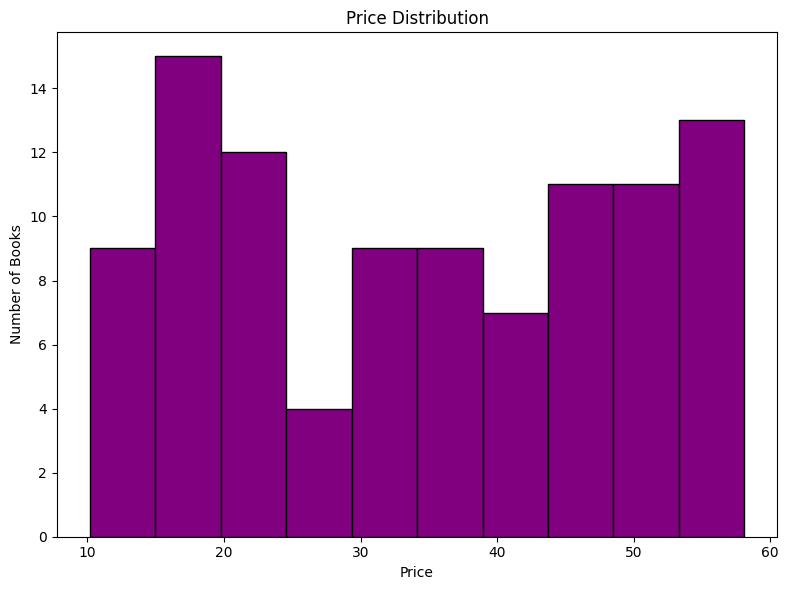

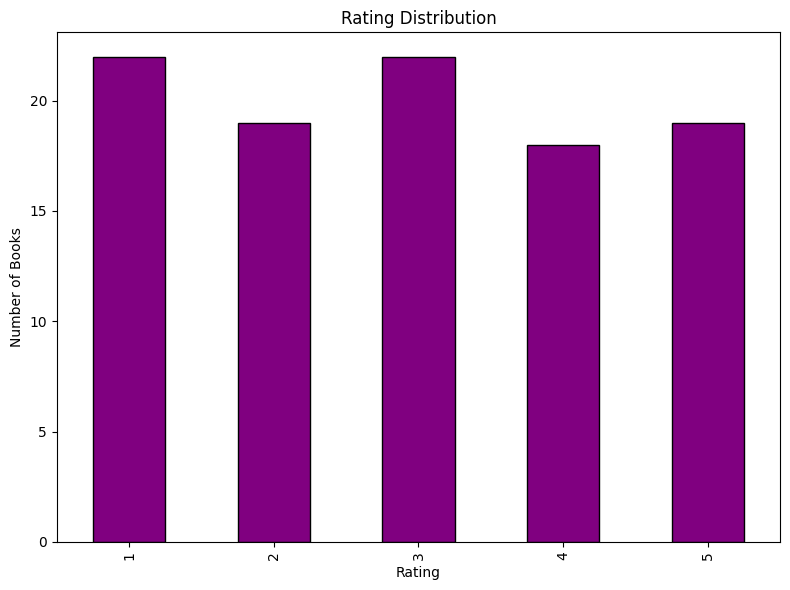

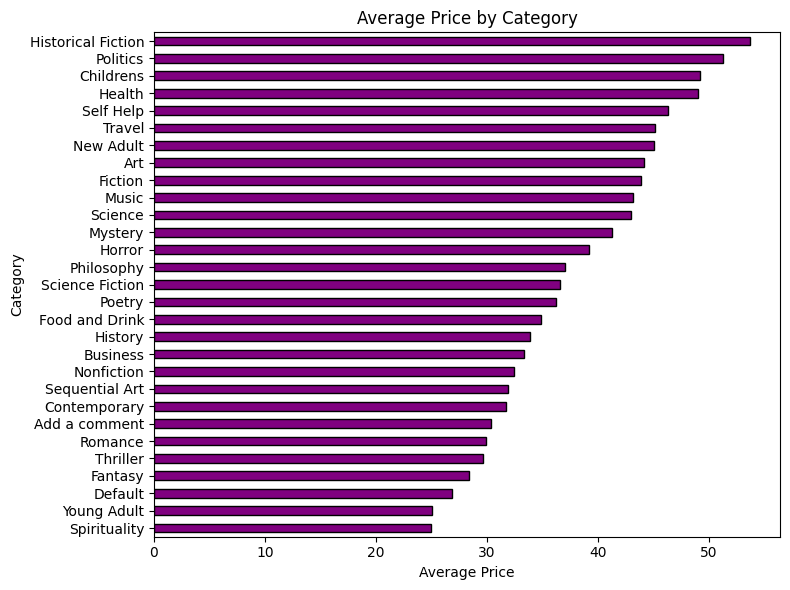

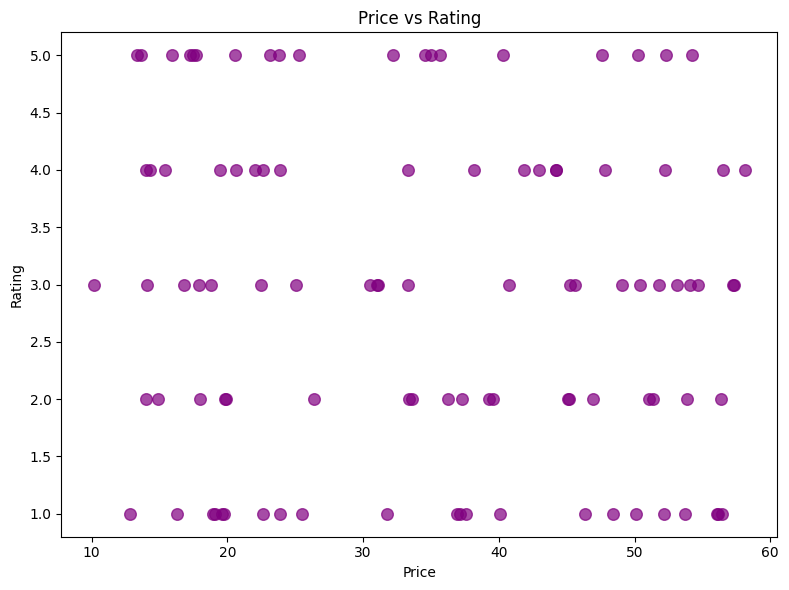

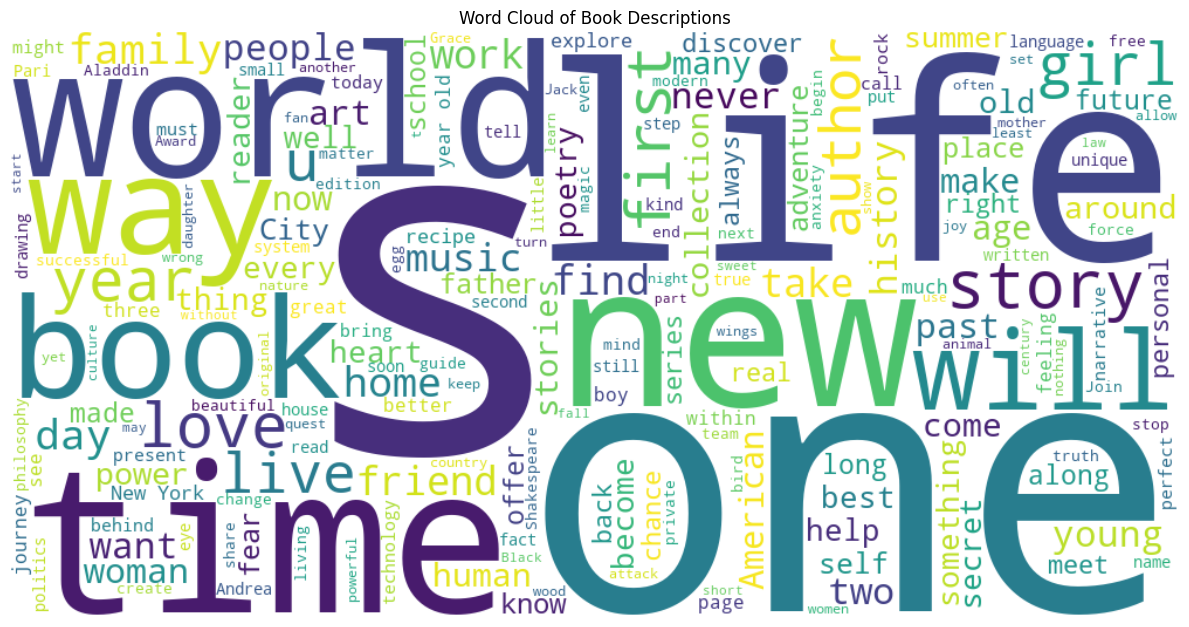


------------ SUMMARY STATISTICS ------------

            price      rating  num_reviews  stock_count  \
count  100.000000  100.000000        100.0   100.000000   
mean    34.560700    2.930000          0.0    17.180000   
std     14.638531    1.423149          0.0     1.479694   
min     10.160000    1.000000          0.0    16.000000   
25%     19.897500    2.000000          0.0    16.000000   
50%     34.775000    3.000000          0.0    16.000000   
75%     47.967500    4.000000          0.0    19.000000   
max     58.110000    5.000000          0.0    22.000000   

       description_word_count  affordability_score  value_score  
count              100.000000           100.000000   100.000000  
mean               224.710000             0.108700     1.857940  
std                107.798474             0.084838     1.428529  
min                 36.000000             0.018000     0.284000  
25%                163.750000             0.051000     0.838750  
50%                211.50

In [26]:
'''Task 3 - Visualization and Analysis
● Generate at least four meaningful plots, including price distribution, rating distribution, average price
by category, and one relationship plot such as price vs rating or category vs stock.
● Generate a word cloud from the combined book descriptions. The selected website does not provide
written customer-review text, so descriptions must be used as the textual source.
● Use summary statistics and plots to identify category patterns, highly rated books, stock patterns, and
any unusual or missing values.'''


import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Load cleaned dataset
df = pd.read_csv("books_clean.csv")


# Price Distribution

plt.figure(figsize=(8,6))
plt.hist(df["price"], bins=10,
    color="purple",
    edgecolor="black"
)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Books")
plt.tight_layout()
plt.savefig("price_distribution.png")
plt.show()


#  Rating Distribution

plt.figure(figsize=(8,6))
df["rating"].value_counts().sort_index().plot(
    kind="bar",
    color="purple",
    edgecolor="black"
)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.tight_layout()
plt.savefig("rat_distribute.png")
plt.show()


#  Average Price by Category

avg_price = df.groupby("category")["price"].mean().sort_values()

plt.figure(figsize=(8,6))
avg_price.plot(
    kind="barh",
    color="purple",
    edgecolor="black"
)
plt.title("Average Price by Category")
plt.xlabel("Average Price")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig("average_price_by_category.png")
plt.show()

# Price vs Ratiing graph

plt.figure(figsize=(8,6))
plt.scatter(df["price"], df["rating"],
        color="purple",
        s=70,
        alpha=0.7)
plt.title("Price vs Rating")
plt.xlabel("Price")
plt.ylabel("Rating")
plt.tight_layout()
plt.savefig("p_vs_r.png")
plt.show()


#  Word Cloud

text = " ".join(df["description"].fillna(""))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(12,8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Book Descriptions")
plt.tight_layout()
plt.savefig("wordcloud.png")
plt.show()

# Summary Statistics

print("\n------------ SUMMARY STATISTICS ------------\n")
print(df.describe())

print("\n=------------ BOOK COUNT BY CATEGORY ------------\n")
print(df["category"].value_counts())

print("\n------------ PRICE BY CATEGORY (Average) ------------\n")
print(df.groupby("category")["price"].mean().sort_values(ascending=False))

print("\n------------ RATING BY CATEGORY (Average) ------------\n")
print(df.groupby("category")["rating"].mean().sort_values(ascending=False))

print("\n------------ MOST EXPENSIVE BOOKS (Top 10) ------------\n")
print(df[["title", "price"]].sort_values(by="price", ascending=False).head(10))

print("\n------------ TOP RATED BOOKS ------------\n")
print(df[df["rating"] == 5][["title", "category", "price"]])

print("\n------------ STOCK SUMMARY ------------\n")
print(df["stock_count"].describe())

print("\n------------ MISSING VALUES ------------\n")
print(df.isnull().sum())